In [107]:
import skysurvey
import slicersim

import matplotlib.pyplot as plt
import numpy as np

import pandas
from astropy import coordinates, units

In [108]:
print(skysurvey.__version__)
print(slicersim.__version__)

0.15.1
0.13.2


# Source

In [2]:
lsst_ddf_hours = {"elias_s1": {"ra": "00 37 48",  "dec":"-44 00 00"},
                  "xmm-lss": {"ra": "02 22 50",  "dec":"-04 45 00"},
                  "chandra-south":{"ra": "03 32 30",  "dec":"-28 06 00"},
                  "cosmos": {"ra": "10 00 24",  "dec":"+02 10 55"},
                  "edfs": {"ra":"-04 04 57.84", "dec": "-48:25:22.8"}
                  }

# To ra dec in degree
lsst_ddfs = {}
for k, v in lsst_ddf_hours.items():
    sky = coordinates.SkyCoord(v["ra"], v["dec"],  unit=(units.hourangle, units.deg))
    lsst_ddfs[k] = {"ra": sky.ra.to("deg").value,
               "dec": sky.dec.to("deg").value,
              }

    
roman_ddfs = {"good-n": {"ra":189.2291667, "dec":+62.2375000},
                "edfs": lsst_ddfs["edfs"].copy()
            }    

In [3]:
import skysurvey
from skysurvey.examples import mocksurvey
from skysurvey.survey import lsst, roman

from shapely import affinity, geometry, ops

In [4]:
lsst_footprint = lsst.get_lsst_footprint()
roman_footprint = roman.get_roman_footprint()
nx, ny = 3, 4 # somewhat like: https://arxiv.org/pdf/2111.03081
romans = [affinity.translate(roman_footprint, xoff=0.7*x_, yoff=0.4*y_) 
          for x_ in range(nx) for y_ in range(ny)]
deep_roman_footprint = ops.unary_union(romans)
glsst = mocksurvey.get_mock_gridsurvey(footprint=lsst_footprint, 
                                      radec=lsst_ddfs)

groman = mocksurvey.get_mock_gridsurvey(footprint=deep_roman_footprint, 
                                      radec=roman_ddfs)

surveys = {"lsst": glsst, 
          "roman": groman,
          "lowz":None}

# Draw Targets

In [5]:
from skysurvey.effects import milkyway

tstart, tstop = "2028-05-01", "2028-07-01"

targets =  {"lsst": skysurvey.SNeIa.from_draw(tstart=tstart, tstop=tstop,
                                    skyarea=glsst.get_skyarea(), # lsst's
                                    zmax=1.8),
     
             "roman": skysurvey.SNeIa.from_draw(tstart=tstart, tstop=tstop,
                                    skyarea=groman.get_skyarea(), # roman's
                                    zmax=2.),
            
            "lowz": skysurvey.SNeIa.from_draw(tstart=tstart, tstop=tstop, # redshift time dilution
                                     radec={"ra_range":[0,360], "dec_range":[-70, 0]},
                                      zmax=0.25,
                                    # add mwebv
                                      model = {"mwebv": {"func": milkyway.get_mwebv, 
                                                          "kwargs":{"ra":"@ra", "dec":"@dec"}}
                                               }
                                     )

           }

# Observe Them

In [6]:


limiting_mag = {"lsst": 24.5, # Fig 11, https://iopscience.iop.org/article/10.3847/1538-4365/ac9e58/pdf
                "roman": 26.6, # https://arxiv.org/pdf/2111.03081 but 26.2 from: https://arxiv.org/pdf/2111.03081
                "lowz": 21. # like LS4
               }
volum_limited = {"lsst": 0.55, # Fig 11, https://iopscience.iop.org/article/10.3847/1538-4365/ac9e58/pdf
                "roman": 1.4, # https://arxiv.org/pdf/2111.03081 but 26.2 from: https://arxiv.org/pdf/2111.03081
                "lowz": 0.15 # like LS4
               }

def get_observed_snia(which, fieldid=None, mwebv_max=0.05, zmax=1.6, 
                     volume_limited=False):
    """ """
    data_ = targets[which].data
    maglim = limiting_mag[which]
    survey = surveys[which]
    
    data = data_[data_["magobs"]<maglim].copy()
    if which != "lowz":
        data["fields"] = survey.radec_to_fieldid(data[["ra","dec"]])
        if fieldid is not None:
            data = data[data["fields"].isin(np.atleast_1d(fieldid))]
    else:
        data["fields"] = None
        if mwebv_max is not None:
            data = data[data["mwebv"]<=mwebv_max]    
            
    if zmax is not None:
        data = data[data["z"]<=zmax]
        
    if volume_limited:
        data = data[data["z"]<=volum_limited[which]]
        
    return data

roman_observed = get_observed_snia("roman", zmax=1.5)
lsst_observed = get_observed_snia("lsst", zmax=0.8)
lowz_observed = get_observed_snia("lowz", zmax=0.15)

# ETC

In [8]:
import slicersim
from slicersim import iotools

config = slicersim.iotools.get_config(scene='supernova.toml')
lazuli = slicersim.Simulation.from_config(config)
#lazuli_prop = dict(#diameter_ext=3.1, diameter_int=0, 
                   #detector__dark=2.8e-3, detector__ron=10,
#                   nmd=(2,8,1), nramp=1
#)

#lazuli.update(**lazuli_prop)

labels = "_lazuli"

# How do you observe

In [13]:
def get_observed_stat(which, fieldid, 
                      simulation, target_snr=20, snr_prop = {},
                      current_radec=None, max_targets=None,  **kwargs):
    """ """
    obs_df = get_observed_snia(which, fieldid=fieldid, **kwargs)
    if max_targets is not None:
        obs_df = obs_df.iloc[:max_targets] # they are random to start with
        
    redshift_in, x1_in, c_in = simulation.get_parameter(["target.redshift",
                                                         "target.x1",
                                                         "target.c"])
    dataout = {}
    
    # Perform initial calibration
    calib_time = perfom_calibration(calib_2d=5*60, # 5 min
                                    calib_3d=10*60, # 10 min
                                    calib_wcc=2*60, # 2 min
                                    )
    
    dataout["fieldcalib"]= {"snr":np.NaN, "exptime":np.NaN,
                              "slewtime":np.NaN, 
                              "calibtime":calib_time}
    
    # loop over targets
    for index_, values in tqdm( list(obs_df.iterrows())) :
        
        # Slew
        new_radec = values["ra"], values["dec"]
        if current_radec is None:
            slew_time = 0
        else: 
            slew_time = slew_to_target(*current_radec, 
                                       *new_radec)
        current_radec = new_radec
            
        # Calibration
        calib_time = perfom_calibration(calib_2d=120, 
                                        calib_3d=0, 
                                        calib_wcc=30
                                       )
        
        
        
        # Target observation    
        redshift, x1, c = values[["z", "x1", "c"]]
        simulation.update(target__redshift=float(redshift), 
                  target__x1=float(x1),
                  target__c=float(c))

        snr_config, snr, exptime = simulation.fetch_snr(target_snr, **snr_prop)
        
        dataout[index_]= snr_config | {"snr":snr, "exptime":exptime,
                                       "slewtime":slew_time, 
                                       "calibtime":calib_time}

    # reset
    simulation.update(target__redshift=redshift_in, 
                       target__x1=x1_in,
                       target__c=c_in)
    # as pandas.DataFrame
    dataout = pandas.DataFrame(dataout).T
    return dataout, current_radec



# Calib
def perfom_calibration(calib_2d=120, calib_3d=0, calib_wcc=0):
    """ """
    return calib_2d+calib_3d+calib_wcc

# Slewing
def slew_to_target(ra_1, dec_1, ra_2, dec_2, 
                   settle_time=45 # ???
                  ):
    """ """
    sep = coordinates.angular_separation(ra_1*units.deg, dec_1*units.deg, 
                                             ra_2*units.deg, dec_2*units.deg
                                        )
    slew_time = get_slewtime(sep.to("deg").value)
    return slew_time + settle_time

def get_slewtime(angsep):
    """ computes the slew time given the angular separation [deg]"""
    return 163.7 + angsep*22.57

In [17]:
import matplotlib.pyplot as plt
from tqdm import tqdm

In [18]:
# Do any  update you what on Lazuli.
# lazuli.update()

current_radec = None
all_df = {}

# LSST
print("LSST")
for field_ in ['elias_s1', 'xmm-lss', 'chandra-south', 'cosmos', 'edfs']:
    print(f"-> LSST {field_=}")
    this_df, current_radec = get_observed_stat("lsst", field_, simulation=lazuli,
                                               current_radec=current_radec,
                                              zmax=0.8)
    this_df = this_df.join(get_observed_snia("lsst", field_)) # add input
    this_df["survey"] = "lsst"
    all_df[field_] = this_df
    

print("low-z")
# low-z (restart from the shared edfs)
this_df, current_radec = get_observed_stat("lowz", None, 
                                           simulation=lazuli,
                                           current_radec=current_radec, 
                                           max_targets=250, zmax=0.15)
this_df = this_df.join(get_observed_snia("lowz", None)) # add input
this_df["survey"] = "lowz"
all_df["lowz"] = this_df

print("Roman")
# Roman (restart from the shared edfs)
for field_ in ['edfs' , 'good-n']:
    print(f"-> Roman {field_=}")
    this_df, current_radec = get_observed_stat("roman", field_, 
                                               simulation=lazuli,
                                               current_radec=current_radec,
                                              zmax=1.5)
    this_df = this_df.join(get_observed_snia("roman", field_)) # add input
    this_df["survey"] = "roman"
    all_df[field_] = this_df


# Data is stored here: all_df

LSST
-> LSST field_='elias_s1'


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [05:45<00:00,  3.35s/it]


-> LSST field_='xmm-lss'


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [03:43<00:00,  2.49s/it]


-> LSST field_='chandra-south'


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [1:12:30<00:00, 17.40s/it]


Roman
-> Roman field_='edfs'


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 220/220 [15:21<00:00,  4.19s/it]


-> Roman field_='good-n'


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 209/209 [17:57<00:00,  5.16s/it]


In [28]:
all_df

{'elias_s1':                   snr  exptime    slewtime calibtime         nmd nramp  \
 fieldcalib        NaN      NaN         NaN    1020.0         NaN   NaN   
 7           19.839204   633.92           0       150  (25, 8, 1)     1   
 8           19.531801   837.68  224.926592       150  (33, 8, 1)     1   
 83          19.650605   659.39  255.915522       150  (26, 8, 1)     1   
 117         19.871293  1296.14   245.08409       150  (51, 8, 1)     1   
 ...               ...      ...         ...       ...         ...   ...   
 2733         20.43831  1168.79  224.573329       150  (46, 8, 1)     1   
 2735        19.696831   812.21  268.487193       150  (32, 8, 1)     1   
 2740        22.380023   3254.5  261.090523       150  (64, 8, 1)     2   
 2824        20.314715  1525.37   230.54424       150  (60, 8, 1)     1   
 2855        22.801063   3254.5  261.725137       150  (64, 8, 1)     2   
 
                   z     x1      c            t0         ra        dec  \
 fieldcalib 

In [31]:
dd = pandas.concat(all_df)
dd.to_csv("/Users/rigault/data/simulation/lazuli/twomonth_baseline.csv")

In [32]:
def get_target_per_years(df):
    """ """
    time_in_hours = df[["exptime", "calibtime", "slewtime"]].sum(axis=1) * units.second.to("h") # times is in hours
    total_time_in_days = time_in_hours.sum() * units.h.to("day")
    ntargets = len(df)
    ntarget_per_years = ntargets / total_time_in_days * 365.25
    return ntarget_per_years



In [33]:
get_target_per_years(dd)

5526.7296901147165

_lazuli takes  3.24 years to observe 10640.0 targets using 50.0% of the telescope time


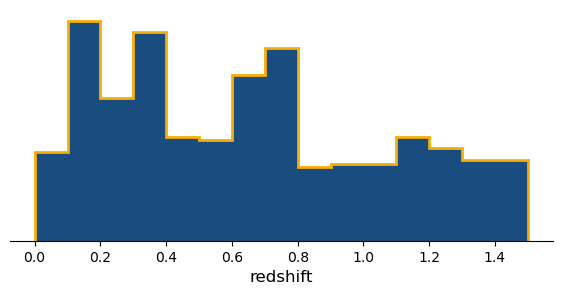

In [50]:
dd_baseline = dd#.xs(0.001)
data_ = pandas.concat([dd_baseline[dd_baseline["z"].between(0,0.2)].sample(frac=0.3),
                       dd_baseline[dd_baseline["z"].between(0.2,0.4)],
                       dd_baseline[dd_baseline["z"].between(0.4,0.6)].sample(frac=0.3),
                       dd_baseline[dd_baseline["z"].between(0.6, 0.8)].sample(frac=0.4), 
                       dd_baseline[dd_baseline["z"].between(0.8, 1.0)].sample(frac=0.6), 
                       dd_baseline[dd_baseline["z"].between(1., 1.2)].sample(frac=0.5), 
                       dd_baseline[dd_baseline["z"].between(1.2, 1.3)].sample(frac=0.5),
                       dd_baseline[dd_baseline["z"].between(1.3, 1.4)].sample(frac=0.3),
                       dd_baseline[dd_baseline["z"]>1.4].sample(frac=0.1),
                      ])
target_per_years_ = get_target_per_years(data_)

fig, ax = plt.subplots(figsize=(7,3))

#sns.kdeplot(x="z", data=data_)
ax.hist(data_["z"], bins=list(np.arange(0, 1.3001, 0.1))+[1.5], density=False, 
        histtype="step", fill=True, lw=2,
        facecolor="#194D80",
        edgecolor="#F8AD05");

ax.set_yticks([])
ax.spines[["left","top","right"]].set_visible(False)
ax.set_xlabel("redshift", fontsize="large")

requested_targets = 8_000 * 1.33
used_telescope_time = 0.50

print(f"{labels} takes { requested_targets/target_per_years_ / used_telescope_time: .3} years to observe {requested_targets} targets using {used_telescope_time:.1%} of the telescope time")
#print(f" -> In one year you get { target_per_years_ * test_percent_in_1year: .0f} targets using {test_percent_in_1year:.1%} of the telescope time")


In [68]:
pandas.DataFrame(data_["nmd"].tolist(), 
                                         columns=("ngroup", "nframe_per_group", "ndrop"),
                index = data_.index)

ngroup  nframe_per_group  ndrop
lowz   648        9                 8      1
       2837       7                 8      1
       1532       5                 8      1
       1538       4                 8      1
       1832       6                 8      1
...             ...               ...    ...
good-n 264       64                 8      1
edfs   667       64                 8      1
good-n 132       64                 8      1
       147       64                 8      1
       452       64                 8      1

[448 rows x 3 columns]

In [94]:
full_data = data_.join(pandas.DataFrame(data_["nmd"].tolist(), 
                                         columns=("ngroup", "nframe_per_group", "ndrop"),
                                       index = data_.index) )
full_data["n_eff_frames"] = full_data["nramp"] * full_data["ngroup"]

In [95]:
full_data.to_csv("/Users/rigault/data/simulation/lazuli/twomonth_optredshift.csv")

Text(0.5, 0, 'redshift')

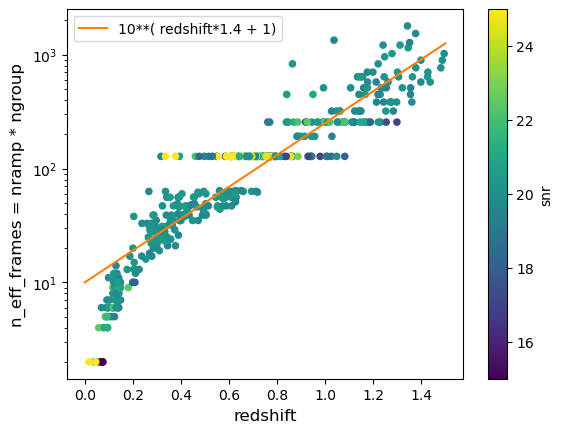

In [93]:
ax = full_data.plot.scatter("z", "n_eff_frames", c="snr", vmin=15, vmax=25)
ax.set_yscale("log")
xx = np.linspace(0, 1.5)
ax.plot(xx, 10**(xx*1.4+1), color="tab:orange", label="10**( redshift*1.4 + 1)")
ax.legend()
ax.set_ylabel("n_eff_frames = nramp * ngroup", fontsize="large")
ax.set_xlabel("redshift", fontsize="large")